# **(ADD THE NOTEBOOK NAME HERE)**

## Objectives

* Write your notebook objective here, for example, "Fetch data from Kaggle and save as raw data", or "engineer features for modelling"

## Inputs

* Write down which data or information you need to run the notebook 

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/nav/Desktop/Fraud-Analysis/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/nav/Desktop/Fraud-Analysis'

# Section 1

Section 1 content

In [ ]:
# Import the necessary libraries
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the cleaned dataset in
df = pd.read_csv('Dataset/CleanData/cleaned_fraud_dataset.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 50000 rows, 20 columns


,Transaction_ID,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label,hour,day_of_week
0,TXN_33553,39.79,POS,93213.17,Laptop,Sydney,Travel,0,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0,19,Monday
1,TXN_9427,1.19,Bank Transfer,75725.25,Mobile,New York,Clothing,0,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1,4,Wednesday
2,TXN_199,28.96,Online,1588.96,Tablet,Mumbai,Restaurants,0,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1,15,Tuesday
3,TXN_12447,254.32,ATM Withdrawal,76807.20,Tablet,New York,Clothing,0,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1,0,Thursday
4,TXN_39489,31.28,POS,92354.66,Mobile,Mumbai,Electronics,1,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1,23,Saturday


---

# Overview
I will look at the dataset before testing any hypothesis, including how balanced the fraud vs genuine transactions are

### Class counts

In [8]:
df['Fraud_Label'].value_counts()

Fraud_Label
0    33933
1    16067
Name: count, dtype: int64

### Class count as %

In [9]:
df['Fraud_Label'].value_counts(normalize=True) * 100

Fraud_Label
0    67.866
1    32.134
Name: proportion, dtype: float64

The dataset contains 33,933 genuine transactions and 16,067 fraudulent transactions meaning roughly 32% of all transactions are fraudulent. This is fairly balanced compared to real-world fraud rates which are usually much lower but it still me gives a meaningful minority class to test against.

# H1 - Recent failed transactions and fraud

Are customers with more failed transactions in the past week more likely to commit fraud?

H0: there is no significant difference in Failed_Transaction_Count_7d between fraudulent and genuine transactions.

H1: Fraudulent Transactions have a significantly higher Failed_Transaction_Count_7d than genuine transactions.


First, a look at the mean, median, and standard deviation of Failed_Transaction_Count_7d for fraudulent vs genuine transactions. This shows whether fraudulent transactions tend to have more failed attempts on average, and whether that pattern is consistent or spread out across the group.


In [10]:
df.groupby('Fraud_Label')['Failed_Transaction_Count_7d'].describe()

,count,mean,std,min,25%,50%,75%,max
Fraud_Label,,,,,,,,
0,33933.0,1.507353,1.121198,0.0,1.0,2.0,3.0,3.0
1,16067.0,3.051472,1.396953,0.0,2.0,4.0,4.0,4.0


In [11]:
df.groupby('Fraud_Label')['Failed_Transaction_Count_7d'].median()

Fraud_Label
0    2.0
1    4.0
Name: Failed_Transaction_Count_7d, dtype: float64

This suggests fraudulent transactions tend to have roughly double the number of failed attempts compared to genuine ones (mean of 3.05 vs 1.51) with the median showing the same pattern (4 vs 2) meaning this difference isn't just being driven by a few extreme cases.

I have done an independent t-test to check whether this difference is statistically significant, or could just be due to random chance.

In [12]:
fraud = df[df['Fraud_Label']==1]['Failed_Transaction_Count_7d']
non_fraud = df[df['Fraud_Label']==0]['Failed_Transaction_Count_7d']

t_stat, p_value = stats.ttest_ind(fraud, non_fraud, equal_var=False)
print(f"t-statistic: {t_stat:.2f}")
print(f"p-value: {p_value}")

t-statistic: 122.65
p-value: 0.0


The p-value is far below 0.05, meaning this result is statistically significant.

I will create a Boxplot to visualise the difference between the two groups.

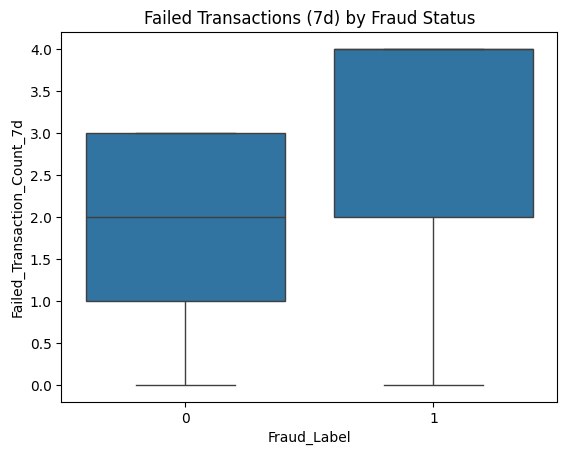

In [14]:
sns.boxplot(x='Fraud_Label', y='Failed_Transaction_Count_7d', data=df)
plt.title('Failed Transactions (7d) by Fraud Status')
plt.show()

Result: Rejected H0 (p < 0.001)

Fraudulent transactions have a noticeably higher average number of failed transactions in the past 7 days (mean 3.05, median 4) compared to genuine transactions (mean 1.51, median 2). This difference is statistically significant. This suggests that repeated failed attempts are a early warning sign of fraud.

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [4]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (553063055.py, line 5)